# CSCI 5527 Deep Learning Project
## Team: Beep Learning

### Get the Data from FER2013

In [2]:
%pip install kaggle
%pip install kagglehub
%pip install torch
%pip install torchvision
%pip install optuna

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms

import kagglehub
import optuna
from optuna.trial import TrialState

# Add project path in a notebook-friendly, cross-platform way
project_root = next(
    (parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / 'fer_dataset.py').exists()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Could not find fer_dataset.py. Run the notebook from the repo root or the vanillaCNN folder.')
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from device_utils import (
    autocast_context,
    build_runtime_config,
    clear_runtime_cache,
    make_dataloader,
    make_grad_scaler,
)
from fer_dataset import FERDataset

runtime = build_runtime_config(max_workers=4)
device = runtime.device
device_type = runtime.device_type
amp_enabled = runtime.amp_enabled
non_blocking = runtime.non_blocking
mps_available = getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available()

print("✓ All libraries imported successfully!")
print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("Torch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", mps_available)
print("Device name:", runtime.device_name)
print(f"\n✓ Device set to: {device} ({device_type})")
print(f"✓ Mixed precision enabled: {amp_enabled}")

✓ All libraries imported successfully!
Python: /usr/local/bin/python3
Torch version: 2.9.0
Torch CUDA version: None
CUDA available: False
MPS available: True
Device name: Apple Silicon GPU (MPS)

✓ Device set to: mps (mps)
✓ Mixed precision enabled: False


## Import Required Libraries

In [4]:
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)

Path to dataset files: /Users/chenyixin/.cache/kagglehub/datasets/msambare/fer2013/versions/1


In [5]:
#!git clone https://github.com/RohitPoduval1/csci5527-project.git

In [6]:
# Verify FERDataset import
print("FERDataset imported successfully!")
print(f"Dataset classes available: {len(FERDataset.__doc__)} emotion types")

FERDataset imported successfully!
Dataset classes available: 161 emotion types


### Load the dataset and split it

In [7]:
# Get the path from kagglehub (you already have this in 'path' variable)
fer_path = path

# Create train and test datasets with transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale images
])

train_dataset = FERDataset(fer_path, split='train', transforms=transform)
test_dataset = FERDataset(fer_path, split='test', transforms=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Emotion classes: {train_dataset.classes}")

Train dataset size: 28709
Test dataset size: 7178
Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [8]:
# Create runtime-aware DataLoaders
train_loader = make_dataloader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    runtime=runtime,
)
test_loader = make_dataloader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    runtime=runtime,
)

print("✓ Runtime-aware DataLoaders created")
print(f"  - device_type: {device_type}")
print(f"  - num_workers: {runtime.num_workers}")
print(f"  - pin_memory: {runtime.pin_memory}")
print(f"  - persistent_workers: {runtime.persistent_workers}")

✓ Runtime-aware DataLoaders created
  - device_type: mps
  - num_workers: 0
  - pin_memory: False
  - persistent_workers: False


In [9]:
class VanillaCNN(nn.Module):
    """Simple CNN for facial emotion recognition"""
    def __init__(self, num_classes=7, dropout_rate=0.25, fc_dropout=0.5):
        super(VanillaCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.bn4 = nn.BatchNorm1d(256)
        self.relu4 = nn.ReLU(inplace=True)
        self.dropout4 = nn.Dropout(fc_dropout)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.relu5 = nn.ReLU(inplace=True)
        self.dropout5 = nn.Dropout(fc_dropout)
        
        self.fc3 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # FC layers
        x = self.fc1(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.dropout4(x)
        
        x = self.fc2(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.dropout5(x)
        
        x = self.fc3(x)
        return x

# Initialize model and move to device
model = VanillaCNN(num_classes=len(train_dataset.classes))
model = model.to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Model parameters: 1,307,591
VanillaCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p

### Train Vanilla CNN (Baseline)

In [10]:
def train_model(model, train_loader, test_loader, num_epochs=50, lr=0.001, patience=10, verbose=True, use_amp=True):
    """
    Train the model and return training history.

    Mixed precision is enabled automatically only when the active runtime supports it.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    amp_active = bool(use_amp and amp_enabled)
    scaler = make_grad_scaler(device_type, amp_active)

    best_val_acc = 0
    patience_counter = 0
    best_model_wts = model.state_dict().copy()

    history = {
        'train_losses': [],
        'val_losses': [],
        'train_accs': [],
        'val_accs': [],
        'best_val_acc': 0,
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=non_blocking)
            labels = labels.to(device, non_blocking=non_blocking)

            optimizer.zero_grad(set_to_none=True)
            with autocast_context(device_type, amp_active):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if scaler is not None:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        history['train_losses'].append(train_loss)
        history['train_accs'].append(train_acc)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device, non_blocking=non_blocking)
                labels = labels.to(device, non_blocking=non_blocking)

                with autocast_context(device_type, amp_active):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                predicted = outputs.argmax(dim=1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(test_loader)
        val_acc = 100 * val_correct / val_total
        history['val_losses'].append(val_loss)
        history['val_accs'].append(val_acc)

        scheduler.step(val_loss)

        if verbose and (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {train_acc:.2f}% ({train_loss:.4f}) | Val: {val_acc:.2f}% ({val_loss:.4f})")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_model_wts)
    history['best_val_acc'] = best_val_acc
    clear_runtime_cache(device_type)
    return history

print("✓ Training function defined with runtime-aware acceleration!")

✓ Training function defined with runtime-aware acceleration!


## Training Execution

### Training Function

## Training

In [11]:
# Train vanilla CNN with default hyperparameters
model_vanilla = VanillaCNN(num_classes=len(train_dataset.classes), dropout_rate=0.25, fc_dropout=0.5)
model_vanilla = model_vanilla.to(device)

print("🚀 Training Vanilla CNN with runtime-aware settings...")
print(f"   Device: {device} ({device_type})")
history_vanilla = train_model(
    model_vanilla, 
    train_loader, 
    test_loader, 
    num_epochs=30, 
    lr=0.001, 
    patience=10,
    use_amp=amp_enabled,
)

print(f"\n✓ Training Complete!")
print(f"  Best Validation Accuracy: {history_vanilla['best_val_acc']:.2f}%")
print(f"  Final Training Accuracy: {history_vanilla['train_accs'][-1]:.2f}%")
print(f"  Final Validation Accuracy: {history_vanilla['val_accs'][-1]:.2f}%")

🚀 Training Vanilla CNN with runtime-aware settings...
   Device: mps (mps)
Epoch [5/30] | Train: 53.11% (1.2452) | Val: 56.06% (1.1432)
Epoch [10/30] | Train: 58.78% (1.1047) | Val: 59.85% (1.0626)
Epoch [15/30] | Train: 62.23% (1.0059) | Val: 60.55% (1.0370)
Epoch [20/30] | Train: 65.60% (0.9200) | Val: 62.32% (1.0123)
Epoch [25/30] | Train: 69.50% (0.8267) | Val: 63.10% (1.0042)
Epoch [30/30] | Train: 71.86% (0.7604) | Val: 63.33% (1.0197)

✓ Training Complete!
  Best Validation Accuracy: 63.51%
  Final Training Accuracy: 71.86%
  Final Validation Accuracy: 63.33%


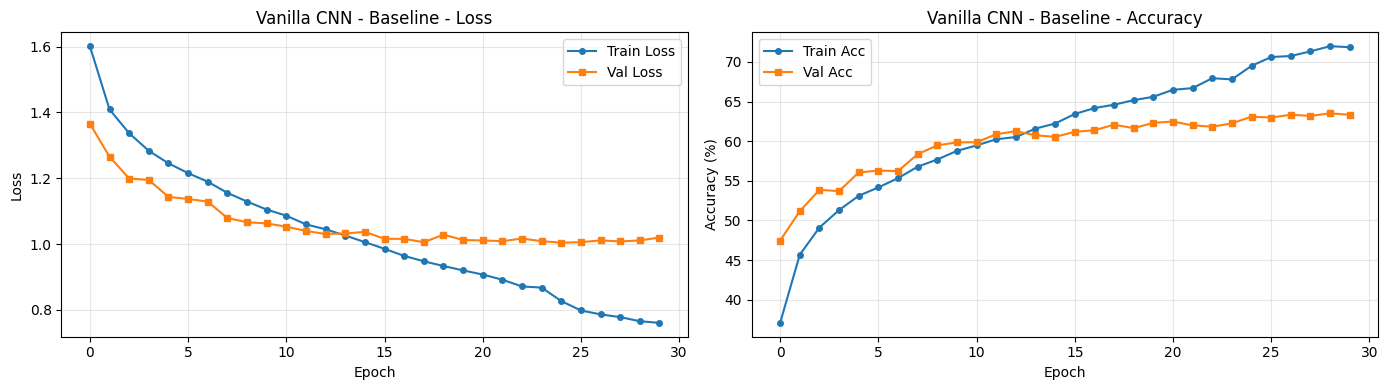

In [12]:
def plot_history(history, title="Training History"):
    """Plot training and validation loss/accuracy"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Loss plot
    ax1.plot(history['train_losses'], label='Train Loss', marker='o', markersize=4)
    ax1.plot(history['val_losses'], label='Val Loss', marker='s', markersize=4)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Accuracy plot
    ax2.plot(history['train_accs'], label='Train Acc', marker='o', markersize=4)
    ax2.plot(history['val_accs'], label='Val Acc', marker='s', markersize=4)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot vanilla CNN results
plot_history(history_vanilla, "Vanilla CNN - Baseline")

### Vanilla CNN Model

Batch shape: torch.Size([32, 1, 48, 48])


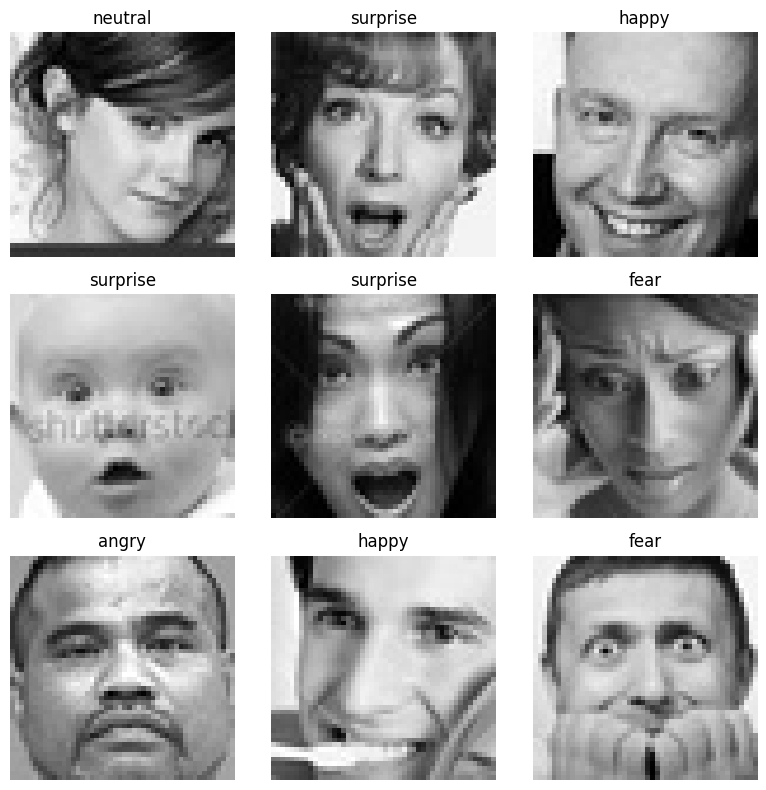

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

# Visualize first 9 images
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i in range(9):
    ax = axes[i // 3, i % 3]
    img = images[i][0].cpu().numpy()
    label = labels[i].item()
    emotion = train_dataset.classes[label]
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Grad-CAM Visualization

Use the trained CNN to visualize which facial regions contribute most to each prediction. This section prefers `model_best` when available and falls back to `model_vanilla`.


Grad-CAM model: Vanilla CNN
Target layer: Conv2d
Sample indices: [0, 1, 2, 3, 4, 5]
Prediction: angry (0.838)
Prediction: fear (0.487)
Prediction: fear (0.830)
Prediction: sad (0.478)
Prediction: happy (0.412)
Prediction: sad (0.439)


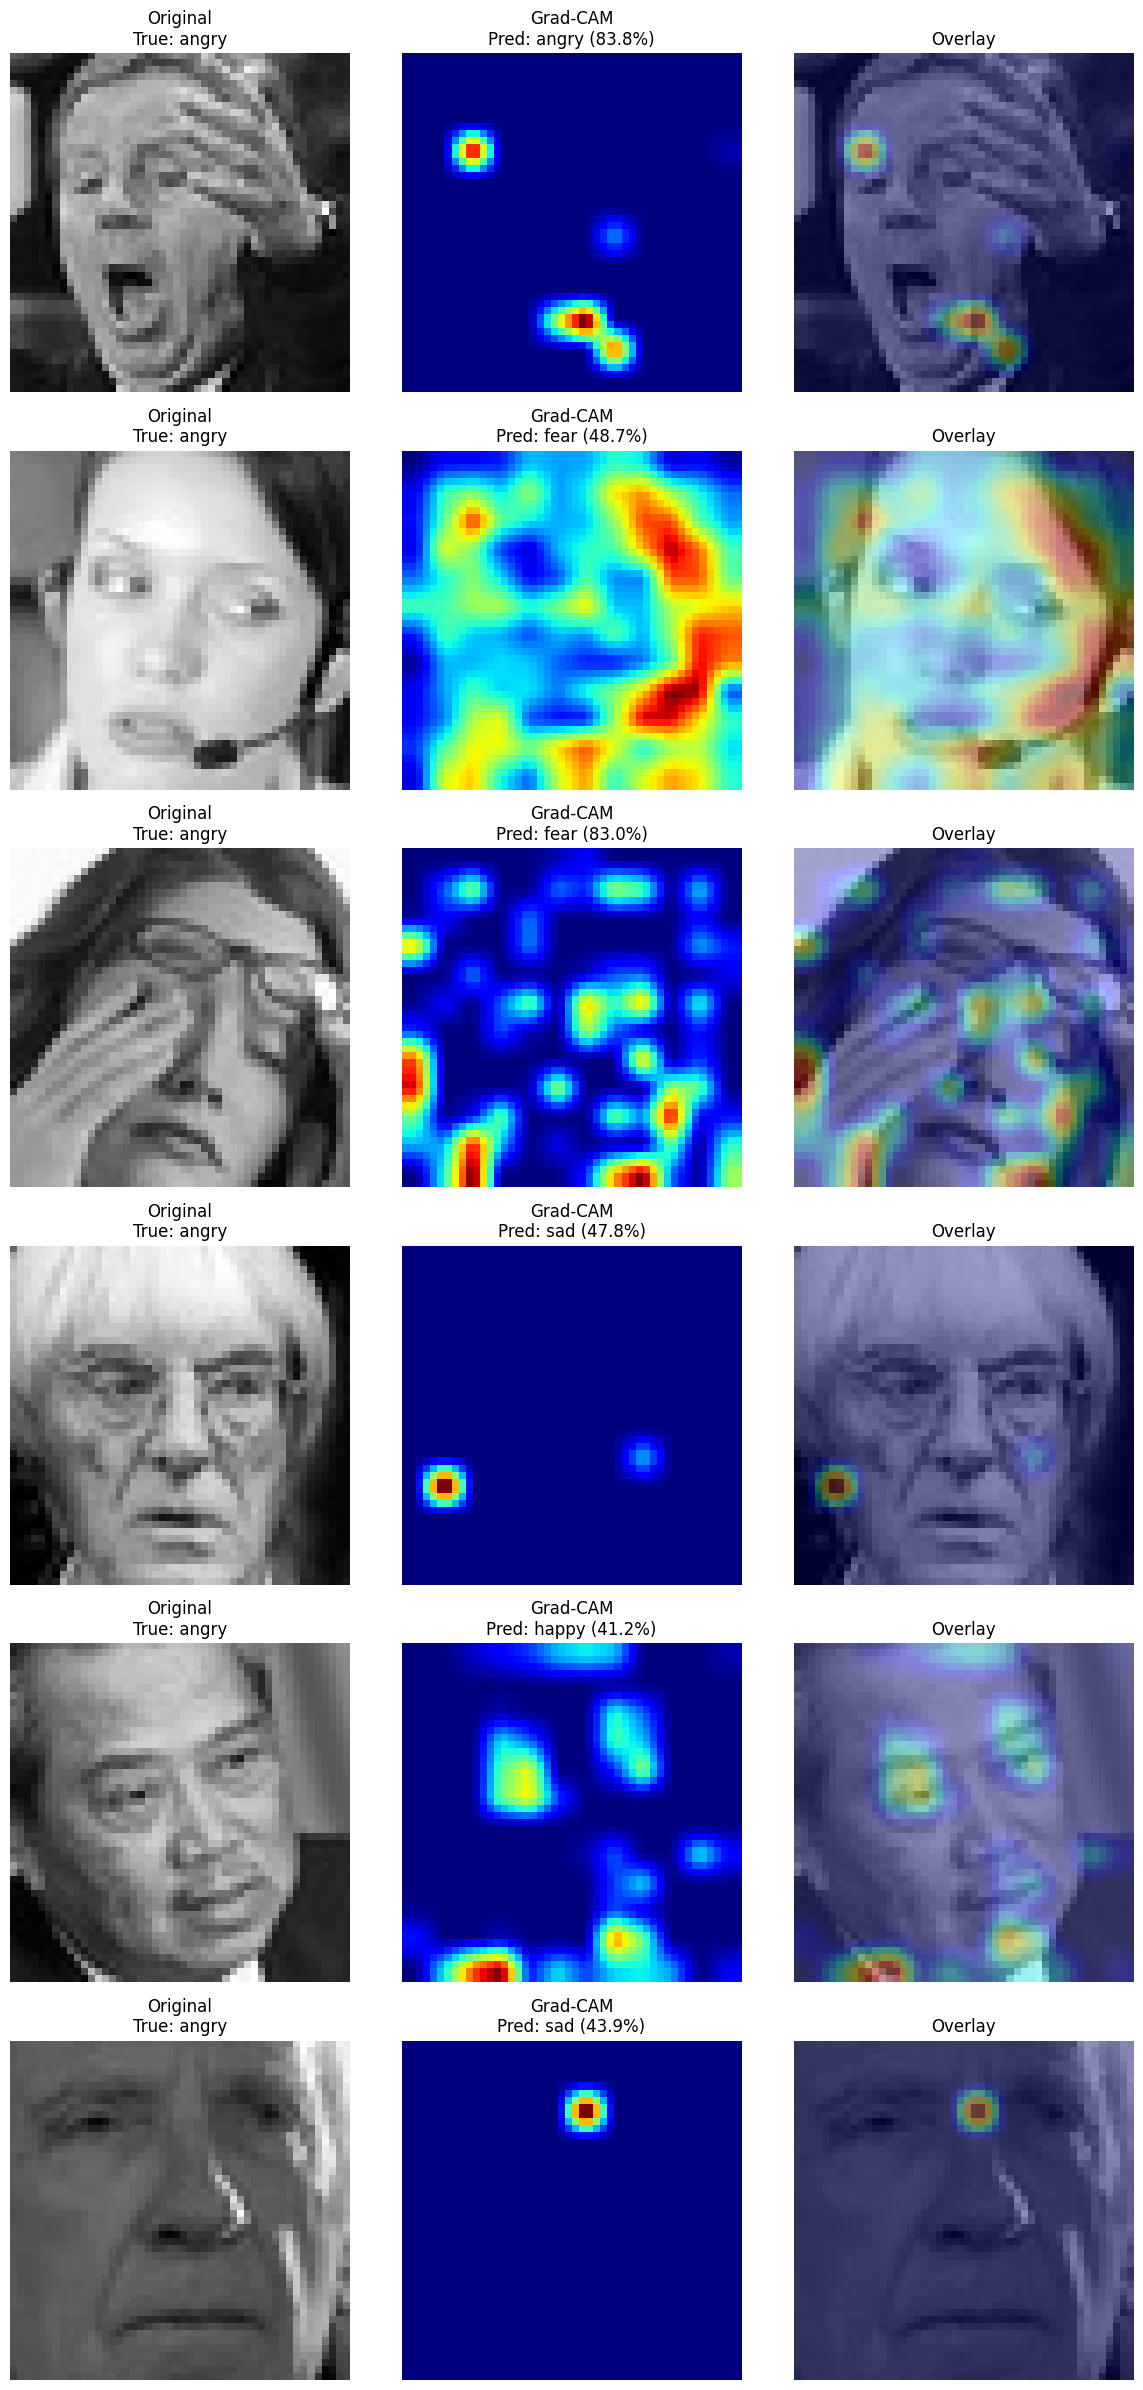

In [14]:
from gradcam_utils import get_default_target_layer, visualize_gradcam_samples

# Choose which trained model to visualize
if 'model_best' in globals():
    gradcam_model = model_best
    gradcam_model_name = 'Optimized CNN'
elif 'model_vanilla' in globals():
    gradcam_model = model_vanilla
    gradcam_model_name = 'Vanilla CNN'
else:
    raise RuntimeError('Train model_vanilla or model_best before running Grad-CAM.')

# Manually choose the target layer
# Replace this with the actual last conv layer in your model if needed
gradcam_target_layer = get_default_target_layer(gradcam_model)

# Just pick the first 6 test samples
gradcam_indices = list(range(6))

print(f"Grad-CAM model: {gradcam_model_name}")
print(f"Target layer: {gradcam_target_layer.__class__.__name__}")
print(f"Sample indices: {gradcam_indices}")

_ = visualize_gradcam_samples(
    model=gradcam_model,
    dataset=test_dataset,
    class_names=train_dataset.classes,
    device=device,
    indices=gradcam_indices,
    target_layer=gradcam_target_layer,
)

Comparing custom Grad-CAM vs pytorch-grad-cam on indices: [0, 1, 2]
Prediction: class 0 (0.838)
Prediction: class 2 (0.487)
Prediction: class 2 (0.830)


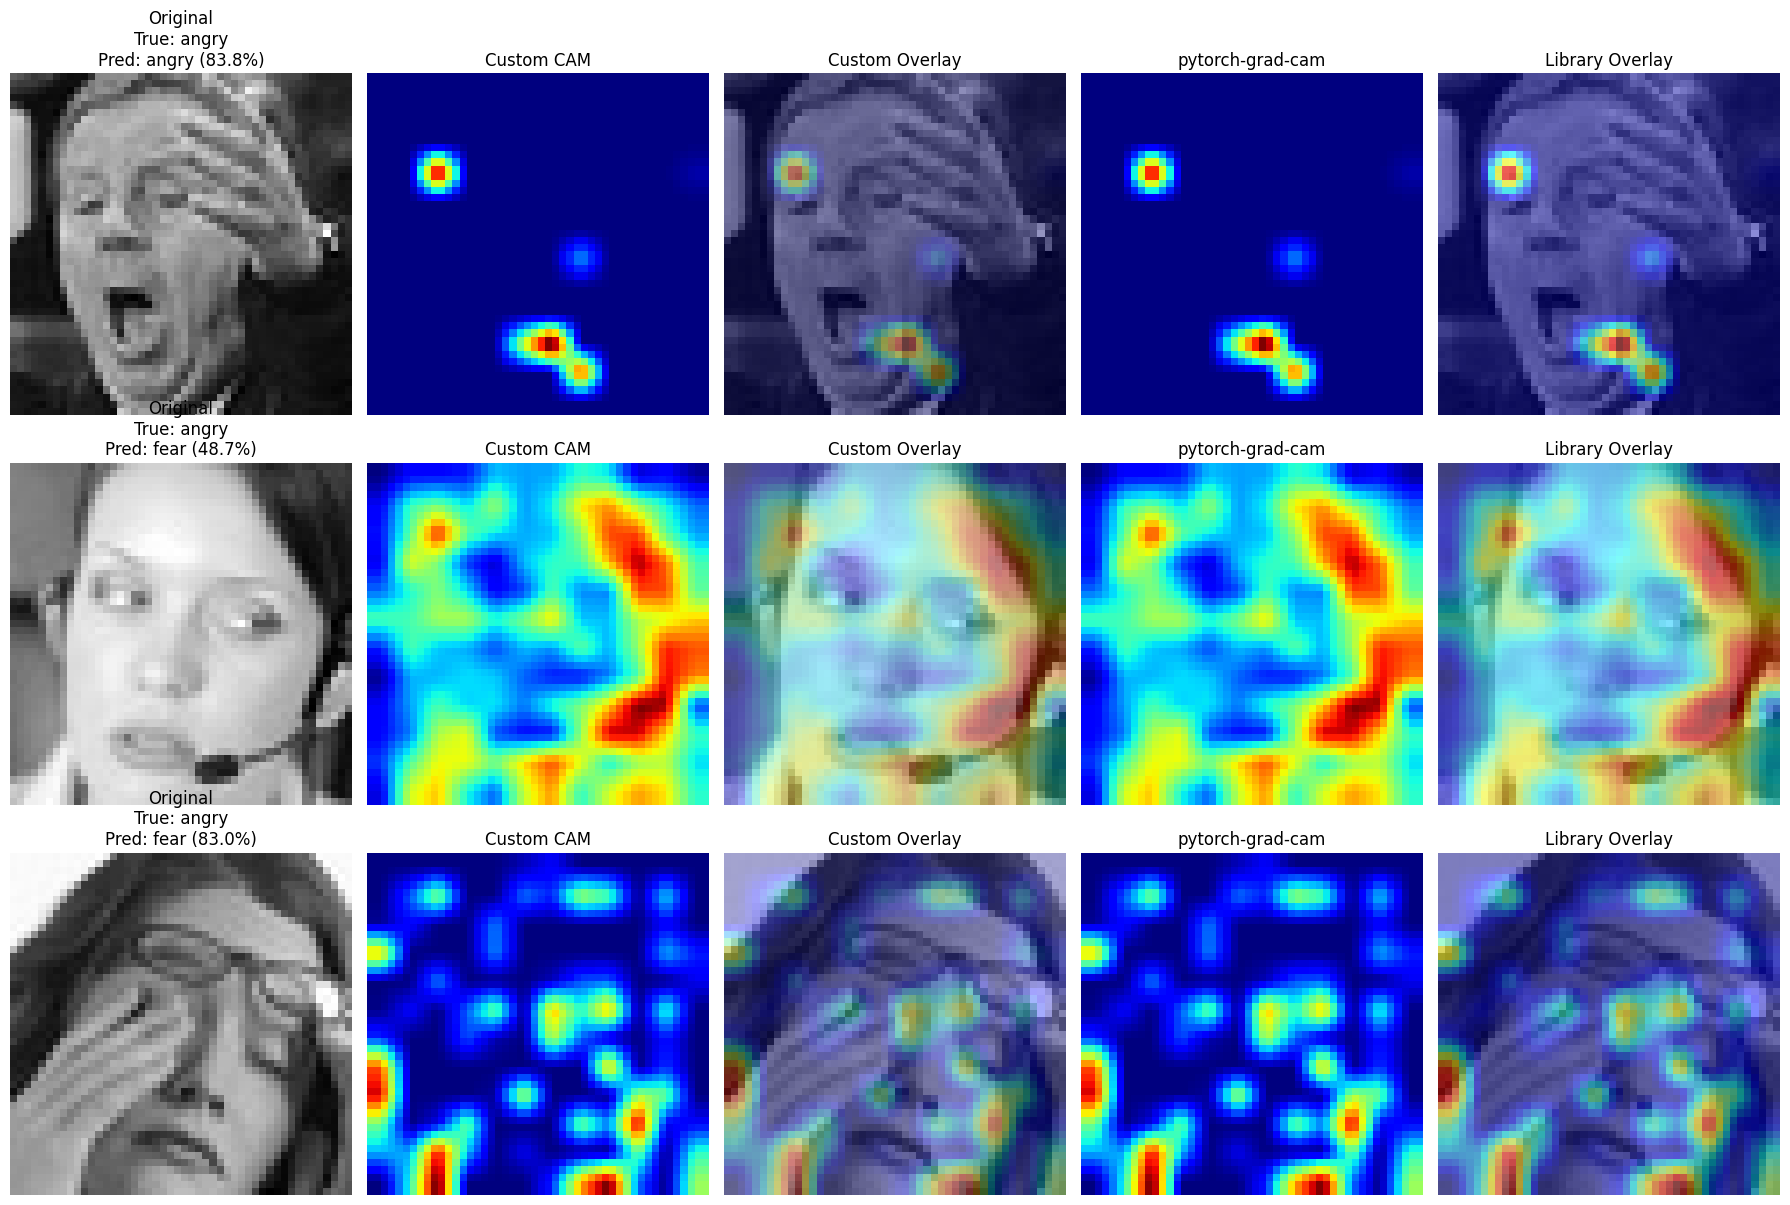

In [15]:
from gradcam_utils import compare_gradcam_methods

comparison_indices = gradcam_indices[:3]
print(f"Comparing custom Grad-CAM vs pytorch-grad-cam on indices: {comparison_indices}")

try:
    _ = compare_gradcam_methods(
        model=gradcam_model,
        dataset=test_dataset,
        class_names=train_dataset.classes,
        device=device,
        indices=comparison_indices,
        target_layer=gradcam_target_layer,
    )
except ImportError as exc:
    print(exc)
